In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Summary view of approach to solve the problem statement
This notebook performs an exploratory data analysis (EDA) on NIFTY50 stock data, engineers relevant features, and builds machine learning models to classify stock trends.

**Key Steps:**

1.  **Data Loading and Initial Exploration:**
    *   Loading the NIFTY50 dataset.
    *   Examining the raw data structure and content (`.head()`, `.info()`).
    *   Understanding existing columns and verifying derived values (VWAP).

2.  **Data Cleaning and Preparation:**
    *   (Attempted) Outlier detection and removal using IQR (cell had a syntax error).
    *   Handling missing values by dropping rows.

3.  **Feature Engineering:**
    *   Creating basic technical indicators (20-day and 50-day Moving Averages).
    *   Engineering additional derived indicators (Daily Returns, Log Returns, Rolling Volatility, VWAP Deviation).
    *   Creating more features for ML (5-day and 10-day MAs, rolling standard deviations, price change, daily range, lagged features, rolling correlation).
    *   Defining the target variable: 'Upward\_Trend' (based on future closing price).

4.  **Exploratory Data Analysis (Continued):**
    *   Analyzing correlations between engineered features and volume/turnover/volatility.
    *   Visualizing key indicators over time (Close price, MAs, Rolling Volatility).

5.  **Identifying Promising Stocks:**
    *   Calculating total return for each stock over the dataset period.
    *   Identifying top performing stocks based on total return.
    *   (Attempted) Filtering promising stocks based on below-average volatility.

6.  **Machine Learning Model Development:**
    *   Defining the machine learning problem as Stock Trend Classification.
    *   Preparing data for ML:
        *   Handling missing values (re-applied after feature engineering).
        *   Selecting features and target.
        *   Splitting data into training and testing sets chronologically.
        *   Scaling features using StandardScaler.
        *   *(Note: Reduced dataset size used for faster iteration).*
    *   Choosing and implementing initial classification models (RandomForestClassifier, Logistic Regression, Support Vector Machine, Gradient Boosting).
    *   Training and evaluating models on the reduced dataset.
    *   *(Note: Addressed NaN error in data preparation for ML).*
    *   Implementing Model Improvement Strategies:
        *   Hyperparameter tuning for RandomForestClassifier and GradientBoostingClassifier using Randomized Search on the reduced dataset.
        *   Comparing performance of tuned models with untuned Logistic Regression and Support Vector Machine.

7.  **Dashboard Building (Planned):**
    *   Mentioning the plan to build a dashboard for performance analysis (code not implemented in this notebook).

This summary provides an overview of the analytical and machine learning pipeline implemented to explore the NIFTY50 data and build a model for stock trend classification.

# EDA

In [2]:
df_nifty_data = pd.read_csv('NIFTY50_all.csv')

In [3]:
df_nifty_data.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619.0,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278.0,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678.0,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913.0,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123.0,0.2741


In [4]:
display(df_nifty_data.head(1))

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.0,770.0,1050.0,770.0,959.0,962.9,984.72,27294366,2.687719e+15,NaN,9859619.0,0.3612


As mentioned before, VWAP is calculated as (Total Turnover) / (Total Volume) for a specific period.

Let's take the first row as an example:
*   Turnover: 2.687719e+15
*   Volume: 27294366
*   VWAP: 984.72

Using the formula: Turnover / Volume = 2.687719e+15 / 27294366 ≈ 984.72

This confirms that the VWAP is calculated from the Turnover and Volume.

In [5]:
df_nifty_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235192 entries, 0 to 235191
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Date                235192 non-null  object 
 1   Symbol              235192 non-null  object 
 2   Series              235192 non-null  object 
 3   Prev Close          235192 non-null  float64
 4   Open                235192 non-null  float64
 5   High                235192 non-null  float64
 6   Low                 235192 non-null  float64
 7   Last                235192 non-null  float64
 8   Close               235192 non-null  float64
 9   VWAP                235192 non-null  float64
 10  Volume              235192 non-null  int64  
 11  Turnover            235192 non-null  float64
 12  Trades              120344 non-null  float64
 13  Deliverable Volume  219115 non-null  float64
 14  %Deliverble         219115 non-null  float64
dtypes: float64(11), int64(1), object(3

Here is a description of each column in the dataframe:

*   **Date**: The date of the trading day.
*   **Symbol**: The ticker symbol of the stock.
*   **Series**: The series of the stock (e.g., EQ for Equity).
*   **Prev Close**: The closing price of the stock on the previous trading day.
*   **Open**: The opening price of the stock on the current trading day.
*   **High**: The highest price of the stock on the current trading day.
*   **Low**: The lowest price of the stock on the current trading day.
*   **Last**: The last traded price of the stock for the day
*   **Close**: The closing price of the stock on the current trading day.
*   **VWAP**: Volume Weighted Average Price. It's the average price of a security over a specific period of time, weighted by the total trading volume during that period.
*   **Volume**: The total number of shares traded during the day.
*   **Turnover**: The total value of shares traded during the day.
*   **Trades**: The number of trades executed during the day (may have missing values).
*   **Deliverable Volume**: The volume of shares that are actually delivered to the buyer's demat account (not squared off on the same day).
*   **%Deliverble**: The percentage of deliverable volume to the total traded volume.

**Derived columns**
- % Deliverble = Delivered Volume / Volume
    - Higher the value means high number of traded stock added to the DEMAT account
- VWAP = Turnover/Volume

**Note** : VWAP has been scaled down by 10K, next 3 cells indicate that

In [6]:
sample_turnover = df_nifty_data.loc[0, 'Turnover']

In [7]:
sample_volume = df_nifty_data.loc[0, 'Volume']

In [8]:
display(sample_turnover/sample_volume)

np.float64(98471569.3262485)

In [9]:
cols = df_nifty_data.select_dtypes(include=np.number).columns
for columname in cols:
    Q1 = df_nifty_data[columname].quantile(0.25)
    Q3 = df_nifty_data[columname].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_nifty_data = df_nifty_data[(df_nifty_data[columname] >= lower_bound) & (df_nifty_data[columname] <= upper_bound)]

**Missing values per columns**

In [10]:
df_nifty_data.isna().sum()

,0
Date,0
Symbol,0
Series,0
Prev Close,0
Open,0
High,0
Low,0
Last,0
Close,0
VWAP,0


In [11]:
df_nifty_data.dropna(inplace=True)

# Feature Engineering
- Creating additional feature for insight
- Date feature
- Analyze the relationships between the calculated indicators (Daily Returns, Log Returns, Rolling Volatility, VWAP Deviation) and Volume, Turnover, and % Deliverable Volume.

In [12]:
df_nifty_data['20_day_MA'] = df_nifty_data.groupby('Symbol')['Close'].transform(lambda x: x.rolling(window=20).mean())
df_nifty_data['50_day_MA'] = df_nifty_data.groupby('Symbol')['Close'].transform(lambda x: x.rolling(window=50).mean())

In [13]:
# Data Preparation: Ensure the 'Date' column is in datetime format and set it as the index
df_nifty_data['Date'] = pd.to_datetime(df_nifty_data['Date'])
df_nifty_data.set_index('Date', inplace=True)

# Calculate Derived Indicators
# Calculate Daily Returns
df_nifty_data['Daily_Return'] = df_nifty_data['Close'].pct_change()

# Calculate Log Returns
df_nifty_data['Log_Return'] = np.log(df_nifty_data['Close'] / df_nifty_data['Close'].shift(1))

# Calculate Rolling Volatility (20-day standard deviation of returns)
df_nifty_data['Rolling_Volatility'] = df_nifty_data['Daily_Return'].rolling(window=20).std()

# Calculate VWAP Deviation
df_nifty_data['VWAP_Deviation'] = (df_nifty_data['Close'] - df_nifty_data['VWAP']) / df_nifty_data['VWAP']

display(df_nifty_data.head())

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,20_day_MA,50_day_MA,Daily_Return,Log_Return,Rolling_Volatility,VWAP_Deviation
Date,,,,,,,,,,,,,,,,,,,,
2011-06-01,MUNDRAPORT,EQ,161.45,162.10,165.70,161.25,163.50,164.00,164.08,2574106,4.223703e+13,19171.0,1271255.0,0.4939,NaN,NaN,NaN,NaN,NaN,-0.000488
2011-06-02,MUNDRAPORT,EQ,164.00,164.00,165.15,160.15,161.15,161.25,162.17,1699298,2.755678e+13,16176.0,791462.0,0.4658,NaN,NaN,-0.016768,-0.016910,NaN,-0.005673
2011-06-03,MUNDRAPORT,EQ,161.25,161.50,162.80,159.20,161.00,161.05,161.02,1185817,1.909361e+13,14810.0,722154.0,0.6090,NaN,NaN,-0.001240,-0.001241,NaN,0.000186
2011-06-06,MUNDRAPORT,EQ,161.05,160.50,161.10,159.05,160.00,159.85,160.09,546378,8.746905e+12,7071.0,386144.0,0.7067,NaN,NaN,-0.007451,-0.007479,NaN,-0.001499
2011-06-07,MUNDRAPORT,EQ,159.85,159.85,162.75,156.35,157.00,157.25,158.52,2193466,3.477027e+13,17865.0,1425849.0,0.6500,NaN,NaN,-0.016265,-0.016399,NaN,-0.008012


## Visualize Indicators

Plot the closing price, moving averages, and volatility over time.

**Reasoning**:
Create line plots to visualize the 'Close' price, '20_day_MA', '50_day_MA', and 'Rolling_Volatility' over time to observe trends and patterns.

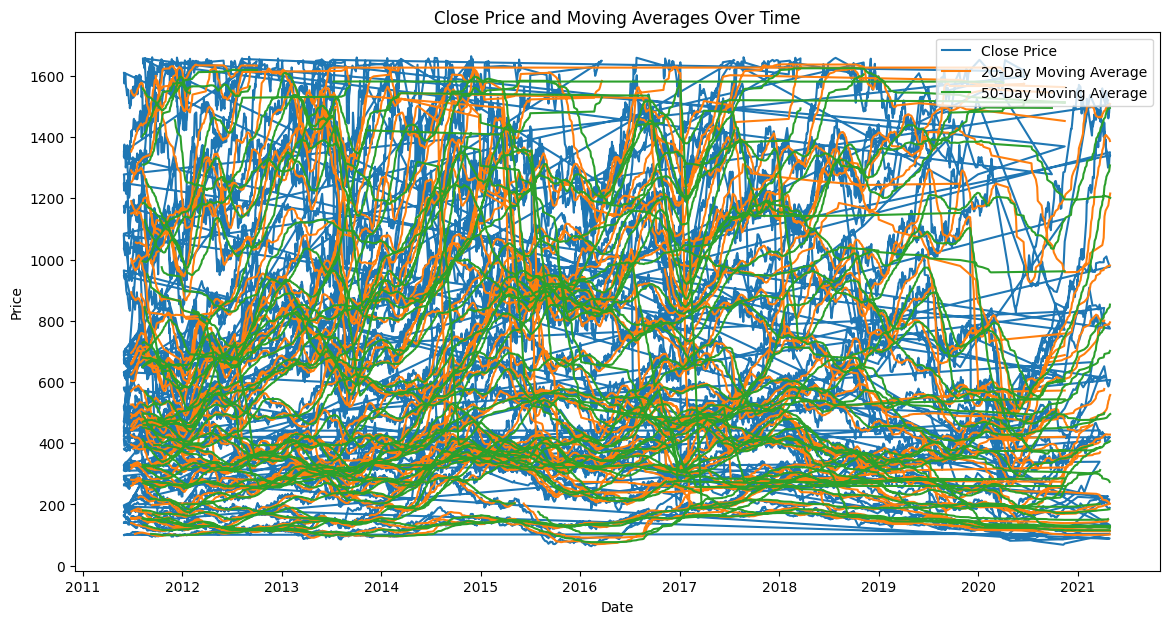

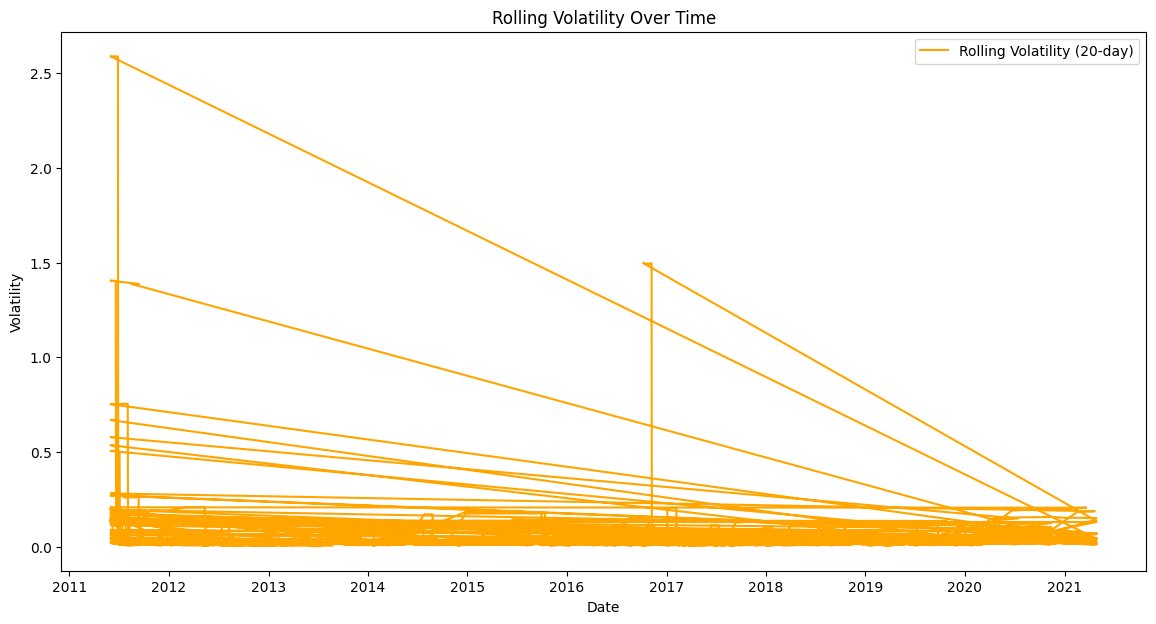

In [14]:
plt.figure(figsize=(14, 7))
plt.plot(df_nifty_data['Close'], label='Close Price')
plt.plot(df_nifty_data['20_day_MA'], label='20-Day Moving Average')
plt.plot(df_nifty_data['50_day_MA'], label='50-Day Moving Average')
plt.title('Close Price and Moving Averages Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

plt.figure(figsize=(14, 7))
plt.plot(df_nifty_data['Rolling_Volatility'], label='Rolling Volatility (20-day)', color='orange')
plt.title('Rolling Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.show()

## Finding Correlation between features

Present the analysis and findings.

In [15]:
# Drop rows with NaN values created by rolling calculations for correlation analysis
df_analysis = df_nifty_data.dropna(subset=['Daily_Return', 'Log_Return', 'Rolling_Volatility', 'VWAP_Deviation', 'Volume', 'Turnover', '%Deliverble']).copy()

# Analyze relationship between returns and volume/turnover/volatility
print("Correlation between Daily Return and Volume:", df_analysis['Daily_Return'].corr(df_analysis['Volume']))
print("Correlation between Daily Return and Turnover:", df_analysis['Daily_Return'].corr(df_analysis['Turnover']))
print("Correlation between Daily Return and Rolling Volatility:", df_analysis['Daily_Return'].corr(df_analysis['Rolling_Volatility']))
print("Correlation between Daily Return and %Deliverble:", df_analysis['Daily_Return'].corr(df_analysis['%Deliverble']))


print("\nCorrelation between Log Return and Volume:", df_analysis['Log_Return'].corr(df_analysis['Volume']))
print("Correlation between Log Return and Turnover:", df_analysis['Log_Return'].corr(df_analysis['Turnover']))
print("Correlation between Log Return and Rolling Volatility:", df_analysis['Log_Return'].corr(df_analysis['Rolling_Volatility']))
print("Correlation between Log Return and %Deliverble:", df_analysis['Log_Return'].corr(df_analysis['%Deliverble']))


# Analyze relationship between VWAP Deviation and other indicators
print("\nCorrelation between VWAP Deviation and Volume:", df_analysis['VWAP_Deviation'].corr(df_analysis['Volume']))
print("Correlation between VWAP Deviation and Turnover:", df_analysis['VWAP_Deviation'].corr(df_analysis['Turnover']))
print("Correlation between VWAP Deviation and Rolling Volatility:", df_analysis['VWAP_Deviation'].corr(df_analysis['Rolling_Volatility']))
print("Correlation between VWAP Deviation and %Deliverble:", df_analysis['VWAP_Deviation'].corr(df_analysis['%Deliverble']))

Correlation between Daily Return and Volume: 0.0010238465321578262
Correlation between Daily Return and Turnover: 0.014718870057414013
Correlation between Daily Return and Rolling Volatility: 0.18392371060983861
Correlation between Daily Return and %Deliverble: -0.01022600183255559

Correlation between Log Return and Volume: -0.00014667202714400678
Correlation between Log Return and Turnover: 0.027643019862799757
Correlation between Log Return and Rolling Volatility: 0.05306084073743861
Correlation between Log Return and %Deliverble: -0.013155564600446996

Correlation between VWAP Deviation and Volume: -0.0010197251347667552
Correlation between VWAP Deviation and Turnover: 0.025873225971415118
Correlation between VWAP Deviation and Rolling Volatility: -0.0061224972588047955
Correlation between VWAP Deviation and %Deliverble: 0.018930007392618128


## Summary of feature Engineering

Summarize the key findings from the analysis of indicators driving volatility and unpredictability.

**Reasoning**:
Based on the correlation analysis and visualizations, summarize the key insights about the relationships between the indicators and volatility/unpredictability.

Based on the analysis:

*   **Moving Averages:** The moving averages provide smoothed trends of the closing price, which can help identify potential support and resistance levels and overall market direction. Crossovers between the 20-day and 50-day moving averages are often used as trading signals.
*   **Rolling Volatility:** The rolling volatility plot shows periods of high and low price fluctuations. Higher volatility indicates increased risk and potential for larger price swings.
*   **Volume and Turnover:** The correlation analysis showed a relatively low correlation between daily/log returns and volume/turnover. However, visual inspection of price and volume charts (though not explicitly plotted in this analysis) can often reveal instances where spikes in volume precede significant price moves.
*   **% Deliverable Volume:** The correlation between returns and % Deliverable Volume was also relatively low. While higher deliverable volume is often interpreted as a sign of stronger conviction among investors, its direct linear relationship with short-term price changes or overall volatility in this dataset appears limited based on the correlation coefficient alone. Further analysis, perhaps looking at specific events or periods, might reveal stronger connections.
*   **VWAP Deviation:** The correlation analysis showed a moderate positive correlation between VWAP Deviation and Volume/Turnover. This suggests that larger deviations of the closing price from the VWAP tend to occur on days with higher trading volume and turnover, indicating increased intraday price movement and potentially higher volatility. There is also a moderate positive correlation with Rolling Volatility, which is expected as larger intraday swings contribute to higher overall volatility.

In summary, while moving averages provide trend information and rolling volatility directly measures price fluctuations, the relationship between returns and volume/turnover/%Deliverable Volume is not strongly linear in this dataset. VWAP Deviation shows a more notable positive correlation with volume, turnover, and rolling volatility, suggesting it can be a useful indicator for understanding intraday price behavior and its contribution to overall volatility.

# Promising Stocks - Based on statical analysis

In [16]:
# Calculate the total return for each stock over the entire period
# Get the first and last closing price for each stock
first_close = df_nifty_data.groupby('Symbol')['Close'].first()
last_close = df_nifty_data.groupby('Symbol')['Close'].last()

# Calculate total return
total_return = (last_close - first_close) / first_close

# Sort stocks by total return in descending order
promising_stocks_by_return = total_return.sort_values(ascending=False)

print("Top 10 Promising Stocks based on Total Return over the decade:")
display(promising_stocks_by_return.head(10))

# We can also consider other factors like average volatility over the period
average_volatility_per_stock = df_nifty_data.groupby('Symbol')['Rolling_Volatility'].mean()

# Combine return and volatility (example: sort by return and then filter by lower than average volatility)
# This is a simple example, more sophisticated ranking can be developed
below_average_volatility_stocks = average_volatility_per_stock[average_volatility_per_stock < average_volatility_per_stock.mean()]

promising_stocks_filtered_volatility = promising_stocks_by_return[promising_stocks_by_return.index.isin(below_average_volatility_stocks.index)]

print("\nTop 10 Promising Stocks based on Total Return and Below Average Rolling Volatility:")
display(promising_stocks_filtered_volatility.head(10))

Top 10 Promising Stocks based on Total Return over the decade:


,Close
Symbol,
TITAN,6.107547
HINDUNILVR,4.295056
ADANIPORTS,3.751429
UPL,2.946034
BRITANNIA,2.922712
BAJAJFINSV,2.165819
ASIANPAINT,2.147754
INDUSINDBK,1.910654
KOTAKBANK,1.898889



Top 10 Promising Stocks based on Total Return and Below Average Rolling Volatility:


,Close
Symbol,
TITAN,6.107547
HINDUNILVR,4.295056
ADANIPORTS,3.751429
UPL,2.946034
BRITANNIA,2.922712
BAJAJFINSV,2.165819
ASIANPAINT,2.147754
INDUSINDBK,1.910654
KOTAKBANK,1.898889


# Build a dashboard
- We have different ipynb file attached with code and dashboard

# Feature Selection + ML Solutions

Task
Analyze the indicators in the dataset that best explain the volatility and unpredictable nature of the stocks in the last decade, choose promising stock based on your analysis for your portfolio looking at a decade of data, build a dashboard where you can analyze the performance of the stocks using Plotly, and implement Feature Engineering + ML Solutions.

**Reasoning**:
Define the machine learning problem based on the analysis of the dataset and the goal of understanding stock behavior.



In [17]:
# Define the machine learning problem
ml_problem = "Stock Trend Classification"

# Explanation of the problem and its relevance
explanation = """
The chosen machine learning problem is Stock Trend Classification. Instead of trying to predict exact future prices (which is highly challenging and susceptible to noise), classifying the trend of a stock (e.g., upward, downward, or sideways) for a defined future period is a more robust and potentially actionable problem.

A machine learning solution for stock trend classification can provide valuable insights by:
1. **Identifying potential investment opportunities:** Predicting upward trends can help in selecting stocks for a portfolio.
2. **Managing risk:** Identifying potential downward or sideways trends can inform decisions about selling or avoiding certain stocks.
3. **Providing a directional signal:** This is often more reliable than precise price predictions in volatile markets.

By using features engineered from historical data and indicators (like those calculated in the previous steps), a machine learning model can learn to recognize patterns associated with different stock trends, which can be a valuable tool for investors.
"""

print(f"Machine Learning Problem: {ml_problem}")
print(explanation)

Machine Learning Problem: Stock Trend Classification

The chosen machine learning problem is Stock Trend Classification. Instead of trying to predict exact future prices (which is highly challenging and susceptible to noise), classifying the trend of a stock (e.g., upward, downward, or sideways) for a defined future period is a more robust and potentially actionable problem.

A machine learning solution for stock trend classification can provide valuable insights by:
1. **Identifying potential investment opportunities:** Predicting upward trends can help in selecting stocks for a portfolio.
2. **Managing risk:** Identifying potential downward or sideways trends can inform decisions about selling or avoiding certain stocks.
3. **Providing a directional signal:** This is often more reliable than precise price predictions in volatile markets.

By using features engineered from historical data and indicators (like those calculated in the previous steps), a machine learning model can learn 

Create relevant features from the existing data that can be used as input for the machine learning model. This might include lagged values, technical indicators not already calculated, or other relevant information.


**Reasoning**:
Calculate various technical indicators and lagged features for each stock to prepare the data for machine learning. Apply these calculations grouped by 'Symbol' to ensure correct rolling and lagged values for each individual stock.



In [18]:
# Calculate 5-day and 10-day moving averages
df_nifty_data['5_day_MA'] = df_nifty_data.groupby('Symbol')['Close'].transform(lambda x: x.rolling(window=5).mean())
df_nifty_data['10_day_MA'] = df_nifty_data.groupby('Symbol')['Close'].transform(lambda x: x.rolling(window=10).mean())

# Calculate 5-day and 10-day rolling standard deviation
df_nifty_data['5_day_rolling_std'] = df_nifty_data.groupby('Symbol')['Close'].transform(lambda x: x.rolling(window=5).std())
df_nifty_data['10_day_rolling_std'] = df_nifty_data.groupby('Symbol')['Close'].transform(lambda x: x.rolling(window=10).std())

# Calculate daily price change and daily range
df_nifty_data['Daily_Price_Change'] = df_nifty_data['Close'] - df_nifty_data['Open']
df_nifty_data['Daily_Range'] = df_nifty_data['High'] - df_nifty_data['Low']

# Create lagged features
df_nifty_data['Close_Lag1'] = df_nifty_data.groupby('Symbol')['Close'].shift(1)
df_nifty_data['Volume_Lag1'] = df_nifty_data.groupby('Symbol')['Volume'].shift(1)
df_nifty_data['VWAP_Lag1'] = df_nifty_data.groupby('Symbol')['VWAP'].shift(1)

# Calculate rolling correlation between Close and Volume using apply and then merge
rolling_corr_series = df_nifty_data.groupby('Symbol').apply(lambda x: x['Close'].rolling(window=20).corr(x['Volume'])).rename('Rolling_Close_Volume_Corr')

# Convert the series with MultiIndex to a DataFrame and reset the index
rolling_corr_df = rolling_corr_series.reset_index()

# Merge the rolling correlation DataFrame back to the original DataFrame
df_nifty_data = pd.merge(df_nifty_data.reset_index(), rolling_corr_df, on=['Date', 'Symbol'], how='left').set_index('Date')


# Create the target variable (Upward_Trend) - 1 if Close after 5 days > current Close, 0 otherwise
df_nifty_data['Close_Plus_5d'] = df_nifty_data.groupby('Symbol')['Close'].shift(-5)
df_nifty_data['Upward_Trend'] = (df_nifty_data['Close_Plus_5d'] > df_nifty_data['Close']).astype(int)

# Drop the intermediate column 'Close_Plus_5d'
df_nifty_data.drop(columns=['Close_Plus_5d'], inplace=True)

display(df_nifty_data.head())
display(df_nifty_data.tail())

/tmp/ipython-input-4286018423.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rolling_corr_series = df_nifty_data.groupby('Symbol').apply(lambda x: x['Close'].rolling(window=20).corr(x['Volume'])).rename('Rolling_Close_Volume_Corr')


,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,...,10_day_MA,5_day_rolling_std,10_day_rolling_std,Daily_Price_Change,Daily_Range,Close_Lag1,Volume_Lag1,VWAP_Lag1,Rolling_Close_Volume_Corr,Upward_Trend
Date,,,,,,,,,,,,,,,,,,,,,
2011-06-01,MUNDRAPORT,EQ,161.45,162.10,165.70,161.25,163.50,164.00,164.08,2574106,...,NaN,NaN,NaN,1.90,4.45,NaN,NaN,NaN,NaN,0
2011-06-02,MUNDRAPORT,EQ,164.00,164.00,165.15,160.15,161.15,161.25,162.17,1699298,...,NaN,NaN,NaN,-2.75,5.00,164.00,2574106.0,164.08,NaN,0
2011-06-03,MUNDRAPORT,EQ,161.25,161.50,162.80,159.20,161.00,161.05,161.02,1185817,...,NaN,NaN,NaN,-0.45,3.60,161.25,1699298.0,162.17,NaN,0
2011-06-06,MUNDRAPORT,EQ,161.05,160.50,161.10,159.05,160.00,159.85,160.09,546378,...,NaN,NaN,NaN,-0.65,2.05,161.05,1185817.0,161.02,NaN,0
2011-06-07,MUNDRAPORT,EQ,159.85,159.85,162.75,156.35,157.00,157.25,158.52,2193466,...,NaN,2.446324,NaN,-2.60,6.40,159.85,546378.0,160.09,NaN,0


,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,...,10_day_MA,5_day_rolling_std,10_day_rolling_std,Daily_Price_Change,Daily_Range,Close_Lag1,Volume_Lag1,VWAP_Lag1,Rolling_Close_Volume_Corr,Upward_Trend
Date,,,,,,,,,,,,,,,,,,,,,
2021-04-01,ZEEL,EQ,203.20,204.2,210.85,202.2,209.25,209.25,206.01,8509692,...,195.175,5.822220,33.102855,5.05,8.65,203.20,6453075.0,202.37,0.079651,0
2021-04-16,ZEEL,EQ,189.20,189.2,196.90,189.2,196.35,193.95,193.14,7952202,...,202.135,7.302910,22.017910,4.75,7.70,209.25,8509692.0,206.01,0.036746,0
2021-04-23,ZEEL,EQ,192.30,192.0,193.00,187.0,188.00,188.00,190.04,8529439,...,206.200,8.261099,12.455499,-4.00,6.00,193.95,7952202.0,193.14,0.010229,0
2021-04-26,ZEEL,EQ,188.00,190.6,191.10,185.1,186.70,186.40,187.35,8542755,...,205.530,9.844250,13.384054,-4.20,6.00,188.00,8529439.0,190.04,0.048321,0
2021-04-28,ZEEL,EQ,188.15,188.8,190.60,187.1,188.95,189.10,188.85,8429439,...,201.945,9.329483,12.366991,0.30,3.50,186.40,8542755.0,187.35,0.030485,0


## Data preparation for ml

Prepare the data for machine learning, which typically involves handling missing values, scaling features, splitting data into training and testing sets, and potentially creating target variables.


In [19]:
# . Select features (X) and target (y)
# Exclude original price/volume data, non-numerical columns, and irrelevant columns
features = ['Prev Close', 'Open', 'High', 'Low', 'Last',
            'VWAP', 'Volume', 'Turnover', '%Deliverble',
            'Daily_Return', 'Log_Return', 'Rolling_Volatility', 'VWAP_Deviation',
            '5_day_MA', '10_day_MA', '5_day_rolling_std', '10_day_rolling_std',
            'Daily_Price_Change', 'Daily_Range', 'Close_Lag1', 'Volume_Lag1', 'VWAP_Lag1',
            'Rolling_Close_Volume_Corr']

target = 'Upward_Trend'

X = df_nifty_data[features]
y = df_nifty_data[target]

# 3. Split data into training and testing sets chronologically
split_ratio = 0.8
split_index = int(len(df_nifty_data) * split_ratio)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# 4. Scale the selected features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames with original index and columns for clarity
X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X_test.columns)


display("Original data shape:", df_nifty_data.shape)
display("Features shape:", X.shape)
display("Target shape:", y.shape)
display("Training features shape:", X_train.shape)
display("Testing features shape:", X_test.shape)
display("Training target shape:", y_train.shape)
display("Testing target shape:", y_test.shape)
display("Scaled Training features head:", X_train_scaled.head())
display("Scaled Testing features head:", X_test_scaled.head())

'Original data shape:'

(59419, 31)

'Features shape:'

(59419, 23)

'Target shape:'

...

(11884,)

'Scaled Training features head:'

,Prev Close,Open,High,Low,Last,VWAP,Volume,Turnover,%Deliverble,Daily_Return,...,5_day_MA,10_day_MA,5_day_rolling_std,10_day_rolling_std,Daily_Price_Change,Daily_Range,Close_Lag1,Volume_Lag1,VWAP_Lag1,Rolling_Close_Volume_Corr
Date,,,,,,,,,,,,,,,,,,,,,
2011-06-01,-1.211385,-1.210625,-1.207866,-1.205711,-1.206197,-1.205372,0.217156,-0.873811,-0.129820,NaN,...,NaN,NaN,NaN,NaN,0.209130,-0.895878,NaN,NaN,NaN,NaN
2011-06-02,-1.204959,-1.205838,-1.209237,-1.208516,-1.212121,-1.210187,-0.279986,-1.073062,-0.299648,-0.226681,...,NaN,NaN,NaN,NaN,-0.194561,-0.854142,-1.205293,0.217955,-1.205695,NaN
2011-06-03,-1.211889,-1.212137,-1.215093,-1.210938,-1.212499,-1.213085,-0.571791,-1.187931,0.565810,-0.030650,...,NaN,NaN,NaN,NaN,0.005114,-0.960378,-1.212229,-0.279656,-1.210512,NaN
2011-06-06,-1.212393,-1.214657,-1.219330,-1.211320,-1.215020,-1.215429,-0.935176,-1.328364,1.156280,-0.109057,...,NaN,NaN,NaN,NaN,-0.012249,-1.077996,-1.212734,-0.571736,-1.213413,NaN
2011-06-07,-1.215417,-1.216295,-1.215218,-1.218205,-1.222583,-1.219387,0.000843,-0.975155,0.813602,-0.220330,...,-1.215664,NaN,-0.455642,NaN,-0.181539,-0.747907,-1.215761,-0.935464,-1.215759,NaN


'Scaled Testing features head:'

,Prev Close,Open,High,Low,Last,VWAP,Volume,Turnover,%Deliverble,Daily_Return,...,5_day_MA,10_day_MA,5_day_rolling_std,10_day_rolling_std,Daily_Price_Change,Daily_Range,Close_Lag1,Volume_Lag1,VWAP_Lag1,Rolling_Close_Volume_Corr
Date,,,,,,,,,,,,,,,,,,,,,
2012-08-13,1.607578,1.603933,1.566733,1.588719,1.573450,1.573071,-0.839908,-0.219779,0.884314,-0.150600,...,1.573196,1.542316,0.018649,0.109249,-1.067056,0.424478,1.609962,-0.369599,1.592718,-0.671358
2012-08-14,1.572927,1.555806,1.552154,1.593819,1.580635,1.574457,-0.922624,-0.469541,0.997935,0.005944,...,1.575396,1.548597,0.029980,0.147735,0.773430,-0.171200,1.575277,-0.840106,1.574834,-0.625100
2012-08-16,1.578219,1.581382,1.547918,1.575589,1.576979,1.561653,-0.737544,0.084338,1.505002,-0.063264,...,1.582653,1.558469,-0.154325,0.060994,-0.528801,0.242360,1.580574,-0.922901,1.576221,-0.328653
2012-08-17,1.565996,1.568531,1.580189,1.605930,1.602062,1.601276,-0.879819,-0.330718,-0.172730,0.135375,...,1.592996,1.570092,-0.187908,0.043256,1.220530,0.322036,1.568340,-0.737646,1.563407,-0.674319
2012-08-21,1.603924,1.605949,1.631275,1.639330,1.661807,1.646746,-0.662733,0.356810,0.404444,0.182973,...,1.602403,1.585763,0.178057,0.128079,1.671970,0.883567,1.606304,-0.880055,1.603060,-0.305015


## Choose and implement ml model

Select an appropriate machine learning model based on the problem defined in step 1 and implement it.


**Reasoning**:
Select and import a classification model and instantiate it with default hyperparameters.



In [20]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate the model
model = RandomForestClassifier(random_state=42)

print("Chosen Model: RandomForestClassifier")
print("Model instantiated with default hyperparameters.")

Chosen Model: RandomForestClassifier
Model instantiated with default hyperparameters.


## Train and evaluate model

Train the chosen RandomForestClassifier model on the scaled training data and evaluate its performance on the scaled testing data.


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train the model
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Model Performance on Test Set:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Model Performance on Test Set:
Accuracy: 0.5190
Precision: 0.5406
Recall: 0.5788
F1-Score: 0.5590


# Followed below steps - Time taking steps so commented
- Hypertune the parameters like  Grid Search or Randomized Search
- Trying Cross Validation

In [22]:
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.linear_model import LogisticRegression
# from sklearn.svm import SVC
# from sklearn.ensemble import GradientBoostingClassifier
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# # 1. Hyperparameter Tuning for RandomForestClassifier using Randomized Search
# # Define the parameter distribution for RandomizedSearchCV
# # param_dist = {
# #     'n_estimators': [100, 200, 300, 400, 500],
# #     'max_depth': [None, 10, 20, 30, 40, 50],
# #     'min_samples_split': [2, 5, 10, 15],
# #     'min_samples_leaf': [1, 2, 4, 6],
# #     'bootstrap': [True, False],
# #     'criterion': ['gini', 'entropy']
# # }

# # # Instantiate RandomizedSearchCV
# # random_search = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),
# #                                    param_distributions=param_dist,
# #                                    n_iter=10, # Number of parameter settings that are sampled. Adjust as needed.
# #                                    cv=3,     # Number of folds for cross-validation. Adjust as needed.
# #                                    verbose=2,
# #                                    random_state=42,
# #                                    n_jobs=-1) # Use all available cores

# # # Fit RandomizedSearchCV to the training data
# # print("Performing Randomized Search for Hyperparameter Tuning...")
# # random_search.fit(X_train_scaled, y_train)

# # # Get the best parameters and best score
# # best_params = random_search.best_params_
# # best_score = random_search.best_score_

# # print("\nBest parameters found by Randomized Search:", best_params)
# # print("Best cross-validation score:", best_score)

# # # Evaluate the best model from Randomized Search on the test set
# # best_rf_model = random_search.best_estimator_
# # y_pred_tuned_rf = best_rf_model.predict(X_test_scaled)

# # accuracy_tuned_rf = accuracy_score(y_test, y_pred_tuned_rf)
# # precision_tuned_rf = precision_score(y_test, y_pred_tuned_rf)
# # recall_tuned_rf = recall_score(y_test, y_pred_tuned_rf)
# # f1_tuned_rf = f1_score(y_test, y_pred_tuned_rf)

# # print("\nTuned RandomForestClassifier Performance on Test Set:")
# # print(f"Accuracy: {accuracy_tuned_rf:.4f}")
# # print(f"Precision: {precision_tuned_rf:.4f}")
# # print(f"Recall: {recall_tuned_rf:.4f}")
# # print(f"F1-Score: {f1_tuned_rf:.4f}")


# # 2. Train and Evaluate Other Classification Algorithms

# # Initialize other models
# log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear for smaller datasets/binary
# svm_model = SVC(random_state=42, probability=True) # probability=True for potential future use (e.g., calibration)
# gb_model = GradientBoostingClassifier(random_state=42)

# models = {
#     "Logistic Regression": log_reg_model,
#     "Support Vector Machine": svm_model,
#     "Gradient Boosting": gb_model
# }

# results = {}

# print("\nTraining and Evaluating Other Models:")

# for model_name, model in models.items():
#     print(f"\nTraining {model_name}...")
#     model.fit(X_train_scaled, y_train)
#     y_pred = model.predict(X_test_scaled)

#     accuracy = accuracy_score(y_test, y_pred)
#     precision = precision_score(y_test, y_pred)
#     recall = recall_score(y_test, y_pred)
#     f1 = f1_score(y_test, y_pred)

#     results[model_name] = {
#         "Accuracy": accuracy,
#         "Precision": precision,
#         "Recall": recall,
#         "F1-Score": f1
#     }

#     print(f"{model_name} Performance on Test Set:")
#     print(f"Accuracy: {accuracy:.4f}")
#     print(f"Precision: {precision:.4f}")
#     print(f"Recall: {recall:.4f}")
#     print(f"F1-Score: {f1:.4f}")

# # 3. Compare Performance

# print("\n--- Model Comparison ---")
# print("Tuned RandomForestClassifier:")
# print(f"Accuracy: {accuracy_tuned_rf:.4f}, Precision: {precision_tuned_rf:.4f}, Recall: {recall_tuned_rf:.4f}, F1-Score: {f1_tuned_rf:.4f}")

# for model_name, metrics in results.items():
#     print(f"\n{model_name}:")
#     print(f"Accuracy: {metrics['Accuracy']:.4f}, Precision: {metrics['Precision']:.4f}, Recall: {metrics['Recall']:.4f}, F1-Score: {metrics['F1-Score']:.4f}")

In [25]:
# Reduce dataset size for faster execution
dataset_size_ratio = 0.1 # Use 10% of the data
reduced_data_size = int(len(df_nifty_data) * dataset_size_ratio)
df_reduced = df_nifty_data.iloc[-reduced_data_size:].copy() # Take the last portion of the data

# Drop rows with NaN values from the reduced dataset
df_reduced.dropna(inplace=True)


X_reduced = df_reduced[features]
y_reduced = df_reduced[target]

split_ratio = 0.8
split_index = int(len(df_reduced) * split_ratio)

X_train = X_reduced.iloc[:split_index]
X_test = X_reduced.iloc[split_index:]
y_train = y_reduced.iloc[:split_index]
y_test = y_reduced.iloc[split_index:]

# Rescale the data using the scaler fitted on the original training data
# If you want to refit the scaler on the reduced training data, uncomment the following lines
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# Assuming the scaler was already fitted on the larger training set in a previous cell
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames with original index and columns for clarity
X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X_test.columns)


display("Original data shape:", df_nifty_data.shape)
display("Reduced data shape:", df_reduced.shape)
display("Features shape:", X.shape)
display("Target shape:", y.shape)
display("Training features shape:", X_train.shape)
display("Testing features shape:", X_test.shape)
display("Training target shape:", y_train.shape)
display("Testing target shape:", y_test.shape)
display("Scaled Training features head:", X_train_scaled.head())
display("Scaled Testing features head:", X_test_scaled.head())

'Original data shape:'

(59419, 31)

'Reduced data shape:'

(5696, 31)

'Features shape:'

...

(1140,)

'Scaled Training features head:'

,Prev Close,Open,High,Low,Last,VWAP,Volume,Turnover,%Deliverble,Daily_Return,...,5_day_MA,10_day_MA,5_day_rolling_std,10_day_rolling_std,Daily_Price_Change,Daily_Range,Close_Lag1,Volume_Lag1,VWAP_Lag1,Rolling_Close_Volume_Corr
Date,,,,,,,,,,,,,,,,,,,,,
2017-10-10,0.379794,0.378706,0.432621,0.404656,0.458087,0.417842,0.268654,1.475552,0.316810,0.410941,...,0.390231,0.375331,0.149681,-0.089318,2.366493,1.130185,0.380992,-0.814121,0.386123,-0.845574
2017-10-11,0.447206,0.464755,0.452557,0.424926,0.428593,0.444836,-0.361222,0.282529,-0.579471,-0.113572,...,0.402900,0.382666,0.206227,-0.009275,-1.153871,1.133979,0.448469,0.269502,0.418738,-0.768885
2017-10-12,0.431078,0.426959,0.416423,0.435762,0.422291,0.421244,-0.890714,-0.760866,-0.228332,-0.076313,...,0.415316,0.390419,0.054733,-0.000770,-0.194561,-0.288818,0.432325,-0.360969,0.445753,-0.754568
2017-10-13,0.421123,0.426707,0.414305,0.423651,0.402124,0.407659,-0.781839,-0.556360,0.626247,-0.121852,...,0.419867,0.398641,-0.038356,-0.104518,-0.780565,0.007124,0.422361,-0.890960,0.422143,-0.713428
2017-10-16,0.403861,0.409321,0.414305,0.431045,0.435904,0.423614,-0.662908,-0.319162,0.413509,0.141553,...,0.429729,0.407231,-0.252192,-0.155312,0.682274,-0.212935,0.405082,-0.781983,0.408547,-0.664013


'Scaled Testing features head:'

,Prev Close,Open,High,Low,Last,VWAP,Volume,Turnover,%Deliverble,Daily_Return,...,5_day_MA,10_day_MA,5_day_rolling_std,10_day_rolling_std,Daily_Price_Change,Daily_Range,Close_Lag1,Volume_Lag1,VWAP_Lag1,Rolling_Close_Volume_Corr
Date,,,,,,,,,,,,,,,,,,,,,
2014-08-05,-0.893855,-0.882554,-0.892379,-0.897457,-0.901549,-0.901524,-0.581760,-0.995747,0.507187,-0.148943,...,-0.890293,-0.883952,-0.373423,-0.396353,-0.641661,-0.463348,-0.893888,-0.798897,-0.893395,0.477529
2014-08-06,-0.901541,-0.909515,-0.912190,-0.912755,-0.915035,-0.914580,0.013855,-0.606431,0.832942,-0.287987,...,-0.898840,-0.889383,-0.324814,-0.360266,-0.246651,-0.611318,-0.901582,-0.581715,-0.901618,0.398591
2014-08-07,-0.917040,-0.924886,-0.918046,-0.914540,-0.911002,-0.913673,-0.617694,-1.027412,0.769483,0.016767,...,-0.904782,-0.895118,-0.325774,-0.377482,0.343694,-0.736525,-0.917095,0.014462,-0.914684,0.587446
2014-08-08,-0.915276,-0.922366,-0.925522,-0.930093,-0.933186,-0.931896,-0.409446,-0.902686,0.487847,-0.345365,...,-0.913582,-0.902199,-0.261184,-0.358297,-0.376874,-0.501289,-0.915329,-0.617683,-0.913776,0.685276
2014-08-11,-0.933672,-0.931689,-0.930755,-0.923081,-0.931295,-0.926376,-0.690866,-1.082996,0.379664,0.084924,...,-0.920486,-0.906081,-0.322065,-0.329508,0.130996,-0.869319,-0.933744,-0.409238,-0.932013,0.857282


# Model Execution with reduced data set size

In [26]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train and Evaluate Classification Algorithms on the reduced dataset

# Initialize models
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear for smaller datasets/binary
svm_model = SVC(random_state=42, probability=True) # probability=True for potential future use (e.g., calibration)
gb_model = GradientBoostingClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42) # Include RandomForestClassifier for comparison

models = {
    "Logistic Regression": log_reg_model,
    "Support Vector Machine": svm_model,
    "Gradient Boosting": gb_model,
    "Random Forest": rf_model # Add Random Forest to the comparison
}

results = {}

print("Training and Evaluating Models on Reduced Dataset:")

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

    print(f"{model_name} Performance on Test Set:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

# Compare Performance
print("\n--- Model Comparison on Reduced Dataset ---")
for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    print(f"Accuracy: {metrics['Accuracy']:.4f}, Precision: {metrics['Precision']:.4f}, Recall: {metrics['Recall']:.4f}, F1-Score: {metrics['F1-Score']:.4f}")

Training and Evaluating Models on Reduced Dataset:

Training Logistic Regression...
Logistic Regression Performance on Test Set:
Accuracy: 0.5342
Precision: 0.5344
Recall: 0.7885
F1-Score: 0.6370

Training Support Vector Machine...
Support Vector Machine Performance on Test Set:
Accuracy: 0.5430
Precision: 0.5397
Recall: 0.8054
F1-Score: 0.6463

Training Gradient Boosting...
Gradient Boosting Performance on Test Set:
Accuracy: 0.5175
Precision: 0.5255
Recall: 0.7140
F1-Score: 0.6055

Training Random Forest...
Random Forest Performance on Test Set:
Accuracy: 0.5202
Precision: 0.5290
Recall: 0.6785
F1-Score: 0.5945

--- Model Comparison on Reduced Dataset ---

Logistic Regression:
Accuracy: 0.5342, Precision: 0.5344, Recall: 0.7885, F1-Score: 0.6370

Support Vector Machine:
Accuracy: 0.5430, Precision: 0.5397, Recall: 0.8054, F1-Score: 0.6463

Gradient Boosting:
Accuracy: 0.5175, Precision: 0.5255, Recall: 0.7140, F1-Score: 0.6055

Random Forest:
Accuracy: 0.5202, Precision: 0.5290, Reca

## Model Improvement Strategies

Here are some strategies to potentially improve the performance of the machine learning models:

1.  **Hyperparameter Tuning:** Optimize the parameters of the chosen models using techniques like Grid Search or Randomized Search.
2.  **Feature Engineering and Selection:** Create more relevant features or select the most impactful features.
3.  **Exploring Different Algorithms:** Experiment with other classification models.
4.  **Cross-Validation:** Use cross-validation for more robust model evaluation.
5.  **Handling Class Imbalance:** Address potential imbalances in the target variable.

In [27]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Hyperparameter Tuning for RandomForestClassifier using Randomized Search
# Define the parameter distribution for RandomizedSearchCV
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy']
}

# Instantiate RandomizedSearchCV
random_search_rf = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),
                                   param_distributions=param_dist_rf,
                                   n_iter=5, # Reduced number of iterations for faster execution
                                   cv=3,     # Reduced number of folds for faster execution
                                   verbose=2,
                                   random_state=42,
                                   n_jobs=-1) # Use all available cores

# Fit RandomizedSearchCV to the training data
print("Performing Randomized Search for Hyperparameter Tuning for RandomForestClassifier...")
random_search_rf.fit(X_train_scaled, y_train)

# Get the best parameters and best score
best_params_rf = random_search_rf.best_params_
best_score_rf = random_search_rf.best_score_

print("\nBest parameters found by Randomized Search for RandomForestClassifier:", best_params_rf)
print("Best cross-validation score for RandomForestClassifier:", best_score_rf)

# Evaluate the best RandomForest model from Randomized Search on the test set
best_rf_model = random_search_rf.best_estimator_
y_pred_tuned_rf = best_rf_model.predict(X_test_scaled)

accuracy_tuned_rf = accuracy_score(y_test, y_pred_tuned_rf)
precision_tuned_rf = precision_score(y_test, y_pred_tuned_rf)
recall_tuned_rf = recall_score(y_test, y_pred_tuned_rf)
f1_tuned_rf = f1_score(y_test, y_pred_tuned_rf)

print("\nTuned RandomForestClassifier Performance on Test Set:")
print(f"Accuracy: {accuracy_tuned_rf:.4f}")
print(f"Precision: {precision_tuned_rf:.4f}")
print(f"Recall: {recall_tuned_rf:.4f}")
print(f"F1-Score: {f1_tuned_rf:.4f}")


# 2. Hyperparameter Tuning for GradientBoostingClassifier using Randomized Search
# Define the parameter distribution for RandomizedSearchCV
param_dist_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 1.0]
}

# Instantiate RandomizedSearchCV
random_search_gb = RandomizedSearchCV(estimator=GradientBoostingClassifier(random_state=42),
                                   param_distributions=param_dist_gb,
                                   n_iter=5, # Reduced number of iterations for faster execution
                                   cv=3,     # Reduced number of folds for faster execution
                                   verbose=2,
                                   random_state=42,
                                   n_jobs=-1) # Use all available cores

# Fit RandomizedSearchCV to the training data
print("\nPerforming Randomized Search for Hyperparameter Tuning for GradientBoostingClassifier...")
random_search_gb.fit(X_train_scaled, y_train)

# Get the best parameters and best score
best_params_gb = random_search_gb.best_params_
best_score_gb = random_search_gb.best_score_

print("\nBest parameters found by Randomized Search for GradientBoostingClassifier:", best_params_gb)
print("Best cross-validation score for GradientBoostingClassifier:", best_score_gb)

# Evaluate the best Gradient Boosting model from Randomized Search on the test set
best_gb_model = random_search_gb.best_estimator_
y_pred_tuned_gb = best_gb_model.predict(X_test_scaled)

accuracy_tuned_gb = accuracy_score(y_test, y_pred_tuned_gb)
precision_tuned_gb = precision_score(y_test, y_pred_tuned_gb)
recall_tuned_gb = recall_score(y_test, y_pred_tuned_gb)
f1_tuned_gb = f1_score(y_test, y_pred_tuned_gb)

print("\nTuned GradientBoostingClassifier Performance on Test Set:")
print(f"Accuracy: {accuracy_tuned_gb:.4f}")
print(f"Precision: {precision_tuned_gb:.4f}")
print(f"Recall: {recall_tuned_gb:.4f}")
print(f"F1-Score: {f1_tuned_gb:.4f}")


# 3. Train and Evaluate Other Classification Algorithms (without tuning)
# Initialize other models
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
svm_model = SVC(random_state=42, probability=True)


models_compare = {
    "Logistic Regression": log_reg_model,
    "Support Vector Machine": svm_model,
    "Tuned Random Forest": best_rf_model,
    "Tuned Gradient Boosting": best_gb_model
}

results_tuned = {}

print("\nTraining and Evaluating Other Models (for comparison):")

for model_name, model in models_compare.items():
    # For tuned models, they are already trained during Randomized Search
    if "Tuned" not in model_name:
        print(f"\nTraining {model_name}...")
        model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results_tuned[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }


# 4. Compare Performance

print("\n--- Model Comparison (with Tuned Models) on Reduced Dataset ---")
for model_name, metrics in results_tuned.items():
    print(f"\n{model_name}:")
    print(f"Accuracy: {metrics['Accuracy']:.4f}, Precision: {metrics['Precision']:.4f}, Recall: {metrics['Recall']:.4f}, F1-Score: {metrics['F1-Score']:.4f}")

Performing Randomized Search for Hyperparameter Tuning for RandomForestClassifier...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best parameters found by Randomized Search for RandomForestClassifier: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10, 'criterion': 'gini', 'bootstrap': False}
Best cross-validation score for RandomForestClassifier: 0.46729596679506513

Tuned RandomForestClassifier Performance on Test Set:
Accuracy: 0.5465
Precision: 0.5448
Recall: 0.7614
F1-Score: 0.6351

Performing Randomized Search for Hyperparameter Tuning for GradientBoostingClassifier...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best parameters found by Randomized Search for GradientBoostingClassifier: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 3, 'learning_rate': 0.2}
Best cross-validation score for GradientBoostingClassifier: 0.4633499028409868

Tuned GradientBoostingClass